<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/research/new_pan_can1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

g65ashaharier21031_demo123_path = kagglehub.dataset_download('g65ashaharier21031/demo123')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/g65ashaharier21031/demo123/marge_data.csv


In [ ]:
"""
Pancancer Prognosis Prediction -- Notebook-Style Walkthrough
=================================================================
Same logic as the class-based pipeline, written as a straight top-to-bottom
script: load -> inspect -> EDA -> preprocess -> split -> encode -> train ->
evaluate. No custom preprocessing classes / sklearn Pipeline objects -- the
only class here is the PyTorch model itself, since nn.Module is how PyTorch
models are defined.

3 IMPROVEMENTS ADDED ON TOP OF THE PREVIOUS VERSION (each explained inline
where it happens):
  A. Early stopping now watches a VALIDATION split carved out of train, not
     the test set. Before, "best_test_cindex" was being chosen by repeatedly
     checking the test set during training -- a subtle form of test leakage
     (you're allowed to look at test exactly once, at the end).
  B. A learning-rate scheduler (ReduceLROnPlateau) backs off the LR once
     validation C-index plateaus, which usually squeezes out a bit more
     performance than a fixed LR for the same training budget.
  C. An optional top-K feature filter keeps only the K numeric columns most
     correlated with survival time (computed on TRAIN only). With gene
     expression data you typically have far more features than patients,
     so cutting ~20,000 genes down to the few thousand most informative
     ones reduces overfitting and tends to raise held-out C-index. Set
     TOP_K_NUMERIC_FEATURES = None to disable and use everything.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

TOP_K_NUMERIC_FEATURES = 2000   # set to None to keep all numeric column

In [ ]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
merged_df = pd.read_csv('/kaggle/input/datasets/g65ashaharier21031/demo123/marge_data.csv')

print(merged_df.shape)
print(merged_df.head())
print(merged_df.info())

/tmp/ipykernel_58/3649069552.py:4: DtypeWarning: Columns (21279,21280,21281,21282,21283,21300,21301,21303,21304,21305,21306,21307,21308,21309,21310,21311,21312,21313,21314,21315,21316,21317,21318,21319,21320,21321,21322,21323,21324,21325,21326,21327,21328,21329,21330,21331,21332,21333,21334,21335,21336,21337,21338,21339,21340,21341,21342,21343,21344,21345,21346,21347,21348,21349,21350,21351,21352,21353,21354,21355,21356,21357,21358,21359,21360,21361,21362,21363,21364,21365,21366,21367,21368,21369,21370,21371,21372,21373,21374,21375,21376,21377,21378,21379,21380,21381,21382,21383,21384,21385,21386,21387,21388,21389,21390,21391,21392,21393,21394,21395,21396,21397,21398,21399,21400,21401,21402,21403,21404,21405,21406,21407,21408,21409,21410,21411,21412,21413,21414,21415,21416,21417,21418,21419,21420,21421,21422,21423,21424,21425,21426,21427,21428,21429,21430,21431,21432,21433,21434,21435,21436,21437,21438,21439,21440,21441,21442,21443,21444,21445,21446,21447,21448,21449,21450,21451,21452,

(9650, 22043)
     Unnamed: 0  gene1   gene2   gene3     gene4    gene5  gene6    gene7  \
0  TCGA-OR-A5J1    0.0  3.2661  3.9385  149.1350  2034.10    0.0  274.255   
1  TCGA-OR-A5J2    0.0  2.6815  8.9948   81.0777  1304.93    0.0  199.302   
2  TCGA-OR-A5J3    0.0  1.7301  6.5650   86.4879  1054.66    0.0  348.393   
3  TCGA-OR-A5J5    0.0  0.0000  1.5492   53.9117  2350.89    0.0  439.194   
4  TCGA-OR-A5J6    0.0  0.0000  4.4709   66.9063  1257.99    0.0  149.215   

    gene8  gene9  ...  treatment_outcome_first_course   OS  OS.time  DSS  \
0  1.4409    0.0  ...     Complete Remission/Response  1.0   1355.0  1.0   
1  0.0000    0.0  ...             Progressive Disease  1.0   1677.0  1.0   
2  0.5925    0.0  ...     Complete Remission/Response  0.0   2091.0  0.0   
3  0.7746    0.0  ...             Progressive Disease  1.0    365.0  1.0   
4  0.0000    0.0  ...     Complete Remission/Response  0.0   2703.0  0.0   

   DSS.time  DFI  DFI.time  PFI  PFI.time  Redaction  
0    1355.0


Top 20 columns by missing %:
prior_glioma                            1.000000
days_to_last_known_alive                0.999482
vascular_tumor_cell_type                0.999275
cholangitis_tissue_evidence             0.998964
Redaction                               0.998446
prior_immunosuppressive_therapy_type    0.998135
bilirubin_lower_limit                   0.996269
creatinine_value_in_mg_dl               0.996269
surgical_procedure_name                 0.996269
creatinine_upper_limit                  0.996269
ca_19_9_level                           0.996269
ca_19_9_level_lower                     0.996269
ca_19_9_level_upper                     0.996269
prothrombin_time_result_value           0.996269
creatinine_lower_level                  0.996269
total_bilirubin_upper_limit             0.996269
albumin_result_lower_limit              0.996269
albumin_result_specified_value          0.996269
platelet_result_upper_limit             0.996269
intern_norm_ratio_upper_limit          

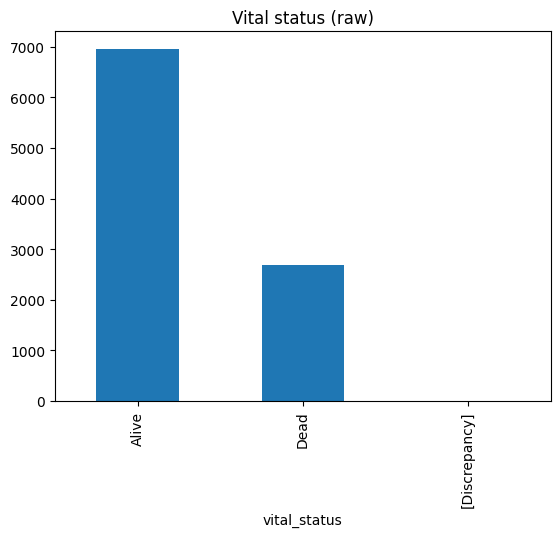

In [ ]:
# =============================================================================
# 2. EDA -- BEFORE CLEANING
# =============================================================================
print("\nTop 20 columns by missing %:")
print(merged_df.isnull().mean().sort_values(ascending=False).head(20))

merged_df['vital_status'].value_counts().plot(kind='bar', title='Vital status (raw)')
plt.show()


# Survival / Follow-up Time Distribution
# The survival (or follow-up) time distribution exhibits a strong right skew.

 This pattern is expected in clinical cancer datasets due to:
 - Predominance of recently diagnosed patients, resulting in shorter follow-up durations
 - Early mortality in a subset of aggressive cases
 - Limited long-term survivors contributing to the extended right tail

 Overall, the distribution reflects typical censoring and survival dynamics observed in pan-cancer cohorts.


Dropped 134 rows with no usable survival time (9515 rows remain).


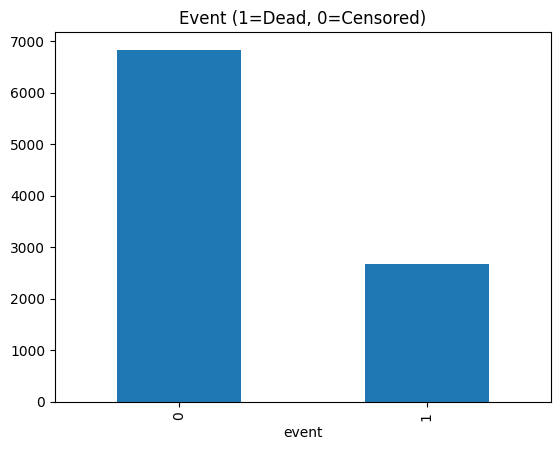

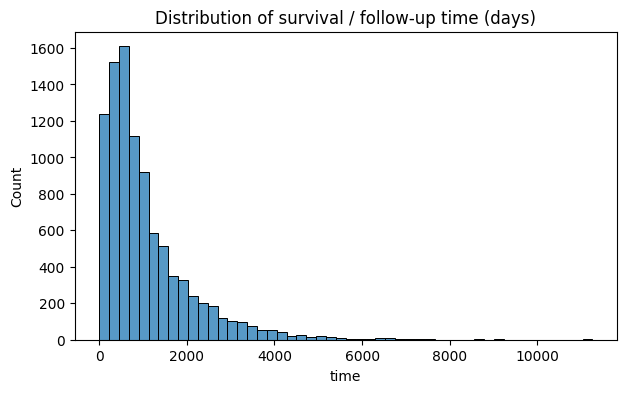

In [ ]:
# =============================================================================
# 3. BUILD SURVIVAL TARGET (time, event) -- do this BEFORE anything else
#    touches vital_status / days_to_death / days_to_last_followup
# =============================================================================
merged_df = merged_df[merged_df['vital_status'].isin(['Alive', 'Dead'])].copy()
merged_df['event'] = (merged_df['vital_status'] == 'Dead').astype(int)

merged_df['days_to_death'] = pd.to_numeric(merged_df['days_to_death'], errors='coerce')
merged_df['days_to_last_followup'] = pd.to_numeric(merged_df['days_to_last_followup'], errors='coerce')
merged_df['time'] = merged_df['days_to_death'].fillna(merged_df['days_to_last_followup'])

# a survival/censoring time can't be imputed -- drop rows where it's missing
before = len(merged_df)
merged_df = merged_df[merged_df['time'].notna() & (merged_df['time'] > 0)].reset_index(drop=True)
print(f"\nDropped {before - len(merged_df)} rows with no usable survival time "
      f"({len(merged_df)} rows remain).")

merged_df['event'].value_counts().plot(kind='bar', title='Event (1=Dead, 0=Censored)')
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(merged_df['time'], bins=50)
plt.title('Distribution of survival / follow-up time (days)')
plt.show()


In [ ]:
# =============================================================================
# 4. MISSING-VALUE PLACEHOLDER CLEANUP
# =============================================================================
missing_placeholders = ["None", "[Not Available]", "Not Available", "NA",
                         "[Not Applicable]", "[Completed]", "[Discrepancy]", "[Unknown]"]
merged_df = merged_df.replace(missing_placeholders, np.nan)
merged_df = merged_df.dropna(axis=1, how='all')

missing_ratio = merged_df.isnull().mean()
print("\nTop 20 columns by missing % (after placeholder cleanup):")
print(missing_ratio.sort_values(ascending=False).head(20))

threshold = 0.6
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c not in ('time', 'event')]   # never drop the target
merged_df = merged_df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns with >{threshold:.0%} missing values.")


/tmp/ipykernel_58/831527626.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df = merged_df.replace(missing_placeholders, np.nan)



Top 20 columns by missing % (after placeholder cleanup):
mpnst_specific_mutations                                                                   0.999895
percent_tumor_sarcomatoid                                                                  0.999895
tmem127                                                                                    0.999895
sdhd                                                                                       0.999895
sdhc                                                                                       0.999895
ss18_ssx_fusion_status                                                                     0.999895
sdhb                                                                                       0.999895
sdhaf2_sdh5                                                                                0.999895
sdha                                                                                       0.999895
pos_finding_metastatic_breast_carcinoma_es

# The columns directly reflect the patient's final outcome or follow-up results, so the prediction in the normal model becomes biased and true generalization is lost.

In [ ]:
# =============================================================================
# 5. DROP ID / ADMIN / TARGET-LEAKAGE COLUMNS
# =============================================================================
id_admin_cols = ['Unnamed: 0', 'bcr_patient_uuid', 'patient_id', 'tissue_source_site',
                  'form_completion_date', 'informed_consent_verified',
                  'days_to_initial_pathologic_diagnosis', 'system_version']

# These ARE (or duplicate) the target -- must never be features, or the model
# is just handed the answer. This is the single biggest lever on a *valid* C-index.
target_leak_cols = ['vital_status', 'days_to_death', 'days_to_last_followup',
                     'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']

# Measured during/after follow-up -- correlates almost tautologically with survival
leakage_risk_cols = ['new_tumor_event_after_initial_treatment', 'treatment_outcome_first_course',
                      'person_neoplasm_cancer_status', 'tumor_status']

drop_cols = [c for c in id_admin_cols + target_leak_cols + leakage_risk_cols if c in merged_df.columns]
merged_df = merged_df.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} ID/admin/leakage columns: {drop_cols}")


Dropped 22 ID/admin/leakage columns: ['Unnamed: 0', 'bcr_patient_uuid', 'patient_id', 'tissue_source_site', 'form_completion_date', 'informed_consent_verified', 'days_to_initial_pathologic_diagnosis', 'system_version', 'vital_status', 'days_to_last_followup', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'new_tumor_event_after_initial_treatment', 'treatment_outcome_first_course', 'person_neoplasm_cancer_status', 'tumor_status']


In [ ]:
# =============================================================================
# 6. NUMERIC-LOOKING OBJECT COLUMNS -> NUMERIC
# =============================================================================
object_cols = merged_df.select_dtypes(include=['object']).columns
for col in object_cols:
    converted = pd.to_numeric(merged_df[col], errors='coerce')
    if converted.notnull().mean() > 0.8:
        merged_df[col] = converted


In [ ]:
merged_df['tissue_retrospective_collection_indicator'].value_counts()

tissue_retrospective_collection_indicator
YES    6086
NO     3049
Name: count, dtype: int64

In [ ]:

# =============================================================================
# 7. BINARY TEXT COLUMNS -> CLEAN 0/1
# =============================================================================
binary_cols = ['gender', 'tissue_retrospective_collection_indicator',
               'tissue_prospective_collection_indicator', 'history_of_neoadjuvant_treatment',
               'radiation_therapy', 'primary_lymph_node_presentation_assessment']
binary_map = {'YES': 1, 'NO': 0, 'MALE': 1, 'FEMALE': 0, 'WITH TUMOR': 1, 'TUMOR FREE': 0}

for col in binary_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype(str).str.upper().str.strip().map(binary_map)


<Axes: >

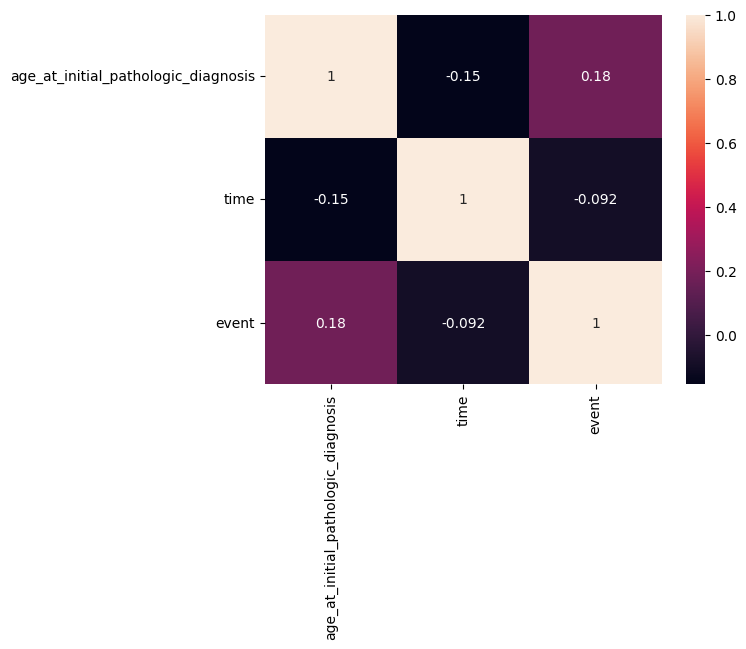

In [ ]:
sns.heatmap(merged_df[['age_at_initial_pathologic_diagnosis', 'time', 'event']].corr(), annot=True)

*

# Age vs Time

1. older patient → shorter survival?
2. younger patient → longer survival?
*


# Time vs Event
1. time বাড়লে event কম হওয়ার chance

# Age vs Event

1. older patients → higher death risk হতে পারে

# What is the survival time of those who have had an event (death = 1) and
# what is the survival time of those who have not had an event (alive = 0)?

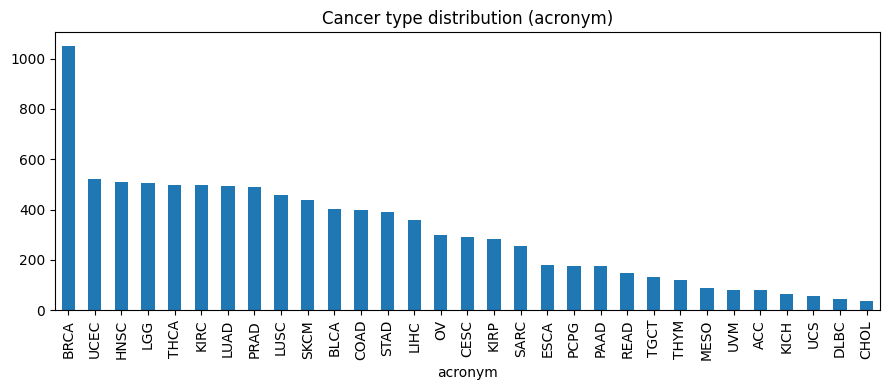

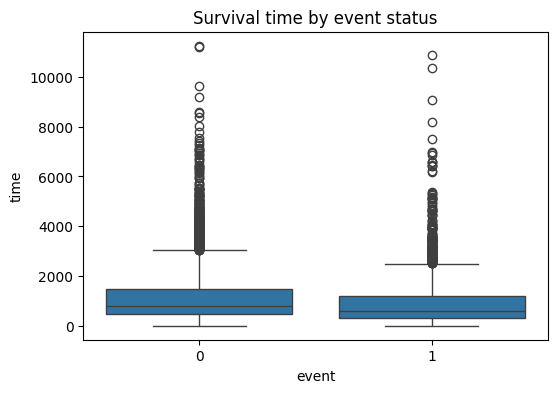


Age / time / event correlation:
                                     age_at_initial_pathologic_diagnosis  \
age_at_initial_pathologic_diagnosis                             1.000000   
time                                                           -0.154768   
event                                                           0.176276   

                                         time     event  
age_at_initial_pathologic_diagnosis -0.154768  0.176276  
time                                 1.000000 -0.092033  
event                               -0.092033  1.000000  


In [ ]:
# =============================================================================
# 8. EDA -- AFTER CLEANING
# =============================================================================
if 'acronym' in merged_df.columns:
    plt.figure(figsize=(9, 4))
    merged_df['acronym'].value_counts().plot(kind='bar')
    plt.title('Cancer type distribution (acronym)')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_df, x='event', y='time')
plt.title('Survival time by event status')
plt.show()

if 'age_at_initial_pathologic_diagnosis' in merged_df.columns:
    print("\nAge / time / event correlation:")
    print(merged_df[['age_at_initial_pathologic_diagnosis', 'time', 'event']].corr())


In [ ]:
# =============================================================================
# 9. IDENTIFY CATEGORICAL COLUMNS, FILL MISSING WITH 'Unknown'
# =============================================================================
cat_cols = merged_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\n{len(cat_cols)} categorical columns remaining: {cat_cols}")

low_card = [c for c in cat_cols if merged_df[c].nunique() <= 5]
mid_card = [c for c in cat_cols if 5 < merged_df[c].nunique() <= 20]
high_card = [c for c in cat_cols if merged_df[c].nunique() > 20]
print(f"low-card: {low_card}\nmid-card: {mid_card}\nhigh-card: {high_card}")

for col in cat_cols:
    merged_df[col] = merged_df[col].astype(str).replace('nan', np.nan).fillna('Unknown')



19 categorical columns remaining: ['acronym', 'icd_10', 'icd_o_3_histology', 'icd_o_3_site', 'tumor_tissue_site', 'race', 'prior_dx', 'ethnicity', 'histological_type', 'pathologic_T', 'pathologic_M', 'pathologic_N', 'pathologic_stage', 'anatomic_neoplasm_subdivision', 'residual_tumor', 'neoplasm_histologic_grade', 'type', 'ajcc_pathologic_tumor_stage', 'histological_grade']
low-card: ['prior_dx', 'ethnicity', 'residual_tumor']
mid-card: ['race', 'pathologic_M', 'pathologic_N', 'pathologic_stage', 'neoplasm_histologic_grade', 'ajcc_pathologic_tumor_stage', 'histological_grade']
high-card: ['acronym', 'icd_10', 'icd_o_3_histology', 'icd_o_3_site', 'tumor_tissue_site', 'histological_type', 'pathologic_T', 'anatomic_neoplasm_subdivision', 'type']


# same proportion of short, medium, long survival patients

In [ ]:
# =============================================================================
# 10. TRAIN / TEST SPLIT -- do this BEFORE fitting any encoder, imputer,
#     variance filter, or scaler, so none of their statistics see the test set
# =============================================================================
y_event = merged_df['event'].values
y_time = merged_df['time'].values
X = merged_df.drop(columns=['time', 'event'])

time_bins = pd.qcut(pd.Series(y_time), q=5, labels=False, duplicates='drop')

X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, y_time, y_event, test_size=0.2, random_state=RANDOM_STATE, stratify=time_bins)

print(f"\nTrain shape: {X_train.shape}  Test shape: {X_test.shape}")



Train shape: (7612, 21305)  Test shape: (1903, 21305)


In [ ]:
y_time_train

array([ 732., 2687.,  819., ...,  200.,  832., 2609.], shape=(7612,))

In [ ]:
# =============================================================================
# 11. ENCODE CATEGORICAL COLUMNS -- one consistent scheme for low/mid/high
#     cardinality, fit on TRAIN only. Index 0 is reserved for "Unknown",
#     which covers missing values AND any category never seen during fit
#     (including categories that only appear in the test split).
# =============================================================================
cat_cols_all = low_card + mid_card + high_card
category_maps = {}

for col in cat_cols_all:
    train_counts = X_train[col].astype(str).value_counts()
    if col in high_card:
        # for high-cardinality columns, drop categories seen fewer than 5
        # times in train into the "Unknown" bucket too, to keep the
        # embedding table from being dominated by one-off categories
        keep_vals = train_counts[train_counts >= 5].index.tolist()
    else:
        keep_vals = train_counts.index.tolist()
    mapping = {v: i + 1 for i, v in enumerate(keep_vals)}   # 0 reserved for Unknown/unseen
    category_maps[col] = mapping
    # print("col = ", col)
    # print(category_maps[col])
    # print("*"*40)
    X_train[col] = X_train[col].astype(str).map(mapping).fillna(0).astype(int)
    X_test[col] = X_test[col].astype(str).map(mapping).fillna(0).astype(int)

cat_cardinalities = [len(category_maps[c]) + 1 for c in cat_cols_all]   # +1 for the Unknown bucket
print("Embedding table sizes:", dict(zip(cat_cols_all, cat_cardinalities)))


Embedding table sizes: {'prior_dx': 7, 'ethnicity': 5, 'residual_tumor': 7, 'race': 8, 'pathologic_M': 9, 'pathologic_N': 19, 'pathologic_stage': 21, 'neoplasm_histologic_grade': 10, 'ajcc_pathologic_tumor_stage': 21, 'histological_grade': 10, 'acronym': 32, 'icd_10': 92, 'icd_o_3_histology': 82, 'icd_o_3_site': 88, 'tumor_tissue_site': 40, 'histological_type': 85, 'pathologic_T': 23, 'anatomic_neoplasm_subdivision': 67, 'type': 32}


In [ ]:
print(4)

4


# TOP_K_NUMERIC_FEATURES

In [ ]:
# =============================================================================
# 12. NUMERIC COLUMNS: IMPUTE -> VARIANCE FILTER -> (optional) TOP-K
#     CORRELATION FILTER -> SCALE. All fit on TRAIN only.
# =============================================================================
num_cols = [c for c in X_train.columns if c not in cat_cols_all]
print(f"\n{len(num_cols)} numeric columns (clinical + gene expression + microRNA, etc.)")

num_imputer = SimpleImputer(strategy='mean')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

# variance filter BEFORE scaling -- after scaling everything has variance ~1
# by construction, so filtering only makes sense on the raw values
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train_num)
keep_mask = var_selector.get_support()
kept_num_cols = [c for c, k in zip(num_cols, keep_mask) if k]
print(f"Variance filter kept {len(kept_num_cols)}/{len(num_cols)} numeric columns.")
X_train_num = X_train_num[kept_num_cols]
X_test_num = X_test_num[kept_num_cols]

# --- IMPROVEMENT C: keep only the K numeric features most correlated with
#     survival time, computed on TRAIN only. Plain Pearson correlation with
#     time is a fast proxy (it ignores censoring), but for very high-
#     dimensional genomic blocks it's a standard, effective way to cut
#     dimensionality before training -- fewer irrelevant gene columns means
#     less overfitting and usually a better held-out C-index.
if TOP_K_NUMERIC_FEATURES is not None and len(kept_num_cols) > TOP_K_NUMERIC_FEATURES:
    vals = X_train_num.values
    t = y_time_train.astype(np.float64)
    t_centered = t - t.mean()
    v_centered = vals - vals.mean(axis=0)
    denom = (vals.std(axis=0) * t.std() + 1e-8)
    corr = (v_centered * t_centered[:, None]).mean(axis=0) / denom
    top_idx = np.argsort(-np.abs(corr))[:TOP_K_NUMERIC_FEATURES]
    kept_num_cols = [kept_num_cols[i] for i in top_idx]
    X_train_num = X_train_num[kept_num_cols]
    X_test_num = X_test_num[kept_num_cols]
    print(f"Top-K filter kept the {TOP_K_NUMERIC_FEATURES} numeric columns "
          f"most correlated with survival time.")

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)



21286 numeric columns (clinical + gene expression + microRNA, etc.)
Variance filter kept 20881/21286 numeric columns.
Top-K filter kept the 2000 numeric columns most correlated with survival time.


In [ ]:
# =============================================================================
# 13. CARVE A VALIDATION SPLIT OUT OF TRAIN (for early stopping / model
#     selection) -- the test set is only looked at once, at the very end
# =============================================================================
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
val_bins = pd.qcut(pd.Series(y_time_train), q=5, labels=False, duplicates='drop')
tr_idx, val_idx = train_test_split(
    np.arange(len(X_train)), test_size=0.15, random_state=RANDOM_STATE, stratify=val_bins)

X_train_num_t = torch.tensor(X_train_num_scaled[tr_idx], dtype=torch.float32, device=device)
X_val_num_t = torch.tensor(X_train_num_scaled[val_idx], dtype=torch.float32, device=device)
X_test_num_t = torch.tensor(X_test_num_scaled, dtype=torch.float32, device=device)

X_train_cat_t = torch.tensor(X_train[cat_cols_all].values[tr_idx], dtype=torch.long, device=device)
X_val_cat_t = torch.tensor(X_train[cat_cols_all].values[val_idx], dtype=torch.long, device=device)
X_test_cat_t = torch.tensor(X_test[cat_cols_all].values, dtype=torch.long, device=device)

time_train_t = torch.tensor(y_time_train[tr_idx], dtype=torch.float32, device=device)
time_val_t = torch.tensor(y_time_train[val_idx], dtype=torch.float32, device=device)
time_test_t = torch.tensor(y_time_test, dtype=torch.float32, device=device)

event_train_t = torch.tensor(y_event_train[tr_idx], dtype=torch.float32, device=device)
event_val_t = torch.tensor(y_event_train[val_idx], dtype=torch.float32, device=device)
event_test_t = torch.tensor(y_event_test, dtype=torch.float32, device=device)

print(f"\nTrain tensor: {X_train_num_t.shape}  Val tensor: {X_val_num_t.shape}  "
      f"Test tensor: {X_test_num_t.shape}")



Train tensor: torch.Size([6470, 2000])  Val tensor: torch.Size([1142, 2000])  Test tensor: torch.Size([1903, 2000])


In [ ]:
# =============================================================================
# 14. MODEL -- the one class in this script, because PyTorch models are
#     defined as nn.Module subclasses; this is the network, not a
#     preprocessing abstraction.
# =============================================================================
class DeepSurvNet(nn.Module):
    def __init__(self, num_numeric_features, cat_cardinalities,
                 hidden_dims=(128, 64, 32), dropout=0.3, max_emb_dim=16):
        super().__init__()
        emb_dims = [min(max_emb_dim, max(2, c // 2)) for c in cat_cardinalities]
        self.embeddings = nn.ModuleList([nn.Embedding(c, d) for c, d in zip(cat_cardinalities, emb_dims)])
        input_dim = num_numeric_features + sum(emb_dims)
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + embs, dim=1) if embs else x_num
        return self.mlp(x).squeeze(-1)


model = DeepSurvNet(num_numeric_features=X_train_num_t.shape[1], cat_cardinalities=cat_cardinalities).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)


In [ ]:
# =============================================================================
# 15. LOSS + METRIC (plain functions, not classes)
# =============================================================================
def cox_ph_loss(log_risk, durations, events):
    """Negative log partial likelihood (Breslow ties), risk set computed
    within the batch: subjects with duration >= the event subject's duration."""
    order = torch.argsort(durations, descending=True)
    log_risk = log_risk[order]
    events = events[order]
    log_cumsum_risk = torch.logcumsumexp(log_risk, dim=0)
    n_events = events.sum().clamp(min=1.0)
    return -torch.sum((log_risk - log_cumsum_risk) * events) / n_events


def concordance_index(time, event, risk):
    try:
        from lifelines.utils import concordance_index as _ci
        return _ci(time, -risk, event)
    except ImportError:
        time, event, risk = np.asarray(time), np.asarray(event), np.asarray(risk)
        n, num, den = len(time), 0, 0
        for i in range(n):
            if event[i] == 0:
                continue
            for j in range(n):
                if time[j] > time[i]:
                    den += 1
                    num += 1 if risk[i] > risk[j] else (0.5 if risk[i] == risk[j] else 0)
        return num / den if den > 0 else float('nan')



In [ ]:
# =============================================================================
# 16. TRAINING LOOP -- early stopping on the VALIDATION split (improvement A)
# =============================================================================
EPOCHS = 500
BATCH_SIZE = 512
PATIENCE = 50

best_val_cindex, best_state, epochs_no_improve = -1.0, None, 0
n_train = X_train_num_t.shape[0]
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(n_train, device=device)
    for start in range(0, n_train, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        risk = model(X_train_num_t[idx], X_train_cat_t[idx])
        loss = cox_ph_loss(risk, time_train_t[idx], event_train_t[idx])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_risk = model(X_val_num_t, X_val_cat_t).cpu().numpy()
    val_cindex = concordance_index(time_val_t.cpu().numpy(), event_val_t.cpu().numpy(), val_risk)
    scheduler.step(val_cindex)   # improvement B
    history.append({'epoch': epoch, 'train_loss': loss.item(), 'val_cindex': val_cindex})

    if val_cindex > best_val_cindex:
        best_val_cindex = val_cindex
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | train_loss {loss.item():.4f} | val_cindex {val_cindex:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
        break

model.load_state_dict(best_state)


epoch   1 | train_loss 4.7863 | val_cindex 0.7318
epoch  10 | train_loss 4.0068 | val_cindex 0.7545
epoch  20 | train_loss 3.4483 | val_cindex 0.7574
epoch  30 | train_loss 3.1965 | val_cindex 0.7580
epoch  40 | train_loss 2.9452 | val_cindex 0.7558
epoch  50 | train_loss 2.9094 | val_cindex 0.7539
Early stopping at epoch 56 (no val improvement for 50 epochs).


<All keys matched successfully>

In [ ]:
# =============================================================================
# 17. FINAL EVALUATION -- test set looked at exactly once, here
# =============================================================================
model.eval()
with torch.no_grad():
    test_risk = model(X_test_num_t, X_test_cat_t).cpu().numpy()
test_cindex = concordance_index(time_test_t.cpu().numpy(), event_test_t.cpu().numpy(), test_risk)

print(f"\nBest validation C-index: {best_val_cindex:.4f}")
print(f"Final TEST C-index:      {test_cindex:.4f}")



Best validation C-index: 0.7840
Final TEST C-index:      0.7701


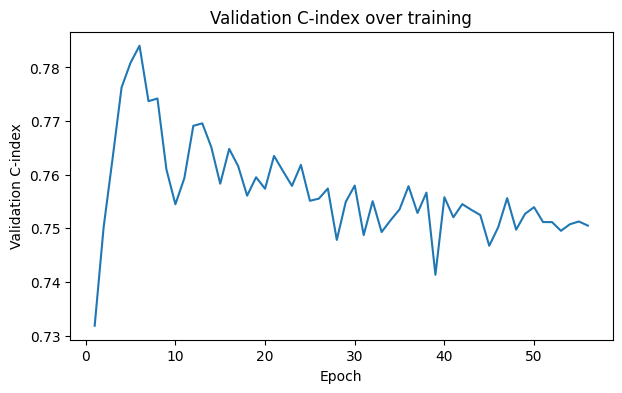

In [ ]:

# =============================================================================
# 18. TRAINING CURVE
# =============================================================================
hist_df = pd.DataFrame(history)
plt.figure(figsize=(7, 4))
plt.plot(hist_df['epoch'], hist_df['val_cindex'])
plt.xlabel('Epoch')
plt.ylabel('Validation C-index')
plt.title('Validation C-index over training')
plt.show()